### Assignment 2: Small Models and Attention

In [1]:
import copy
import csv
import random
import re
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader, TensorDataset

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### Question 1 : Softer Targets
Use this FashionMNIST MLP. Flatten each image before passing it to the model.

```python
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)
```

Use Adam, learning rate 0.001, batch size 128, and 10 epochs.

##### Part (a) : Train and Report
Train two models from identical initial weights, using these two training losses:

```python
hard_loss = nn.CrossEntropyLoss(label_smoothing=0.0)
soft_loss = nn.CrossEntropyLoss(label_smoothing=0.1)
```

The soft target is 0.91 for the true class and 0.01 for each other class. Validation and test always use the hard loss.

For each model, report the selected epoch, test accuracy, and mean test confidence. Confidence is the largest softmax probability:

```python
confidence = torch.softmax(logits, dim=-1).max(dim=-1).values
```

In [2]:
# Loading FashionMNIST dataset

transform = transforms.ToTensor() #transforms images to Tensors
all_training = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=transform
)
test_data = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=transform
)
g = torch.Generator().manual_seed(42)
order = torch.randperm(60000, generator=g).tolist()
train_data = Subset(all_training, order[:6000])
val_data = Subset(all_training, order[6000:7000])

In [3]:
# Dataset Loaders
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=0, drop_last=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=0, drop_last=False)

# Building both models from identical weights
set_seed(42)
hard_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
).to(device)
soft_model = copy.deepcopy(hard_model)

In [4]:
# Evaluation
eval_criterion = nn.CrossEntropyLoss(reduction="sum") #reduction parameter to account for uneven btach sizes

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_confidences = []
    
    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            logits = model(images)
            loss = eval_criterion(logits, targets)
            total_loss += loss.item()
            
            probs = torch.softmax(logits, dim=-1)
            conf, preds = probs.max(dim=-1)
            
            total_correct += (preds == targets).sum().item()
            total_samples += targets.size(0)
            all_confidences.append(conf.cpu())
            
    mean_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    confidences = torch.cat(all_confidences)
    mean_confidence = confidences.mean().item()
    
    return mean_loss, accuracy, mean_confidence, confidences


In [5]:
def train_and_evaluate(model, train_loss_fn, model_name):
    print(f"\n{'='*20} {model_name} {'='*20}")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Fresh loader with seed 42 so both models see identical batch sequences
    train_loader = DataLoader(
        train_data,
        batch_size=128,
        shuffle=True,
        num_workers=0,
        drop_last=False,
        generator=torch.Generator().manual_seed(42),
    )
    
    best_val_loss = float("inf")
    best_epoch = -1
    best_weights = None
    
    for epoch in range(1, 11):
        model.train()
        train_loss_sum = 0.0
        train_samples = 0
        
        for images, targets in train_loader:
            images, targets = images.to(device), targets.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = train_loss_fn(logits, targets)
            loss.backward()
            optimizer.step()
            
            train_loss_sum += loss.item() * targets.size(0)
            train_samples += targets.size(0)
            
        train_loss = train_loss_sum / train_samples
        val_loss, val_acc, _, _ = evaluate(model, val_loader)
        print(f"Epoch {epoch:2d}/10 | Train Loss: {train_loss:.4f} | Val Loss (Hard): {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
        
        # Save checkpoint if lowest validation loss so far
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_weights = copy.deepcopy(model.state_dict())
            
    print(f"\nSelected Best Epoch: Epoch {best_epoch} (Val Loss = {best_val_loss:.4f})")
    
    # Restore the best weights before test evaluation
    model.load_state_dict(best_weights)
    test_loss, test_acc, test_conf, test_confidences = evaluate(model, test_loader)
    
    return best_epoch, test_acc, test_conf, test_confidences

In [6]:
# Define the two losses
hard_loss = nn.CrossEntropyLoss(label_smoothing=0.0)
soft_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

# Train and evaluate both models
best_epoch_hard, test_acc_hard, test_conf_hard, confs_hard = train_and_evaluate(
    hard_model, hard_loss, "Model 1: Hard Targets (smoothing=0.0)"
)

best_epoch_soft, test_acc_soft, test_conf_soft, confs_soft = train_and_evaluate(
    soft_model, soft_loss, "Model 2: Soft Targets (smoothing=0.1)"
)

# Print Summary Table for Q1(a)
print("\n" + "="*70)
print(f"{'Model':<25} | {'Selected Epoch':<15} | {'Test Accuracy':<15} | {'Mean Confidence':<15}")
print("-" * 70)
print(f"{'Hard (smoothing=0.0)':<25} | Epoch {best_epoch_hard:<9} | {test_acc_hard*100:.2f}% ({test_acc_hard:.4f})  | {test_conf_hard:.4f}")
print(f"{'Soft (smoothing=0.1)':<25} | Epoch {best_epoch_soft:<9} | {test_acc_soft*100:.2f}% ({test_acc_soft:.4f})  | {test_conf_soft:.4f}")
print("="*70)



==================== Model 1: Hard Targets (smoothing=0.0) ====================
Epoch  1/10 | Train Loss: 1.1903 | Val Loss (Hard): 0.7546 | Val Acc: 73.00%
Epoch  2/10 | Train Loss: 0.7025 | Val Loss (Hard): 0.6328 | Val Acc: 78.20%
Epoch  3/10 | Train Loss: 0.5959 | Val Loss (Hard): 0.5530 | Val Acc: 80.20%
Epoch  4/10 | Train Loss: 0.5456 | Val Loss (Hard): 0.5328 | Val Acc: 81.70%
Epoch  5/10 | Train Loss: 0.5045 | Val Loss (Hard): 0.4974 | Val Acc: 83.60%
Epoch  6/10 | Train Loss: 0.4827 | Val Loss (Hard): 0.4999 | Val Acc: 82.10%
Epoch  7/10 | Train Loss: 0.4576 | Val Loss (Hard): 0.4798 | Val Acc: 83.70%
Epoch  8/10 | Train Loss: 0.4489 | Val Loss (Hard): 0.4593 | Val Acc: 85.00%
Epoch  9/10 | Train Loss: 0.4262 | Val Loss (Hard): 0.4639 | Val Acc: 82.90%
Epoch 10/10 | Train Loss: 0.4119 | Val Loss (Hard): 0.4775 | Val Acc: 83.30%

Selected Best Epoch: Epoch 8 (Val Loss = 0.4593)

==================== Model 2: Soft Targets (smoothing=0.1) ====================
Epoch  1/10 | Trai

##### Part (b) : Compare Confidence
Plot both test-confidence histograms on one axis. Use the same 20 equal-width bins from 0 to 1 and label the two models.


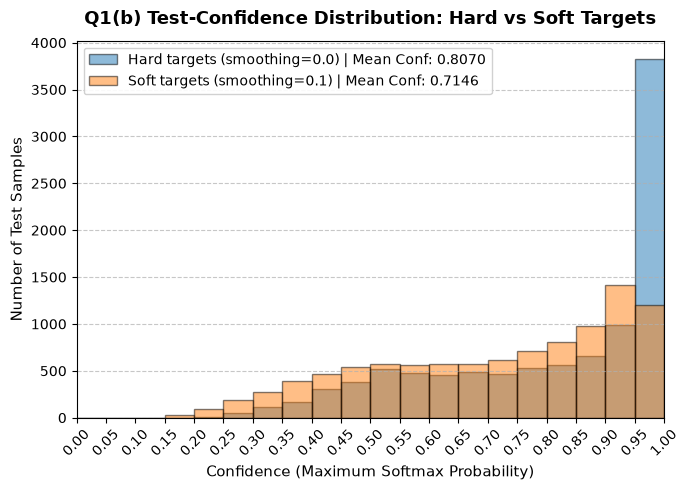

In [7]:
plt.figure(figsize=(7, 5))
bins = np.linspace(0.0, 1.0, 21)

plt.hist(
    confs_hard.numpy(),
    bins=bins,
    alpha=0.5,
    color="#1f77b4",
    edgecolor="black",
    label=f"Hard targets (smoothing=0.0) | Mean Conf: {test_conf_hard:.4f}",
)
plt.hist(
    confs_soft.numpy(),
    bins=bins,
    alpha=0.5,
    color="#ff7f0e",
    edgecolor="black",
    label=f"Soft targets (smoothing=0.1) | Mean Conf: {test_conf_soft:.4f}",
)
plt.title("Q1(b) Test-Confidence Distribution: Hard vs Soft Targets", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Confidence (Maximum Softmax Probability)", fontsize=11)
plt.ylabel("Number of Test Samples", fontsize=11)
plt.xticks(bins, rotation=45)
plt.xlim(0.0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(fontsize=10, loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.show()

##### Part (c) : Explain
In three or four sentences, describe the changes in accuracy and confidence. Why do softer targets reduce the pressure toward extreme confidence? Refer to your results, even if accuracy did not improve.


In our FashionMNIST experiment, introducing label smoothing preserved test accuracy with a slight increase from **82.26% to 82.54%**, while significantly reducing the mean test confidence from **0.8070 to 0.7146**. With hard one-hot targets, cross-entropy loss reaches zero only when the winning logit diverges to positive infinity relative to all other logits ($z_{\text{true}} - z_j \to +\infty$), creating persistent gradient pressure that inflates weight magnitudes and drives predictions into the extreme $[0.95, 1.0]$ confidence bin. In contrast, softer targets ($0.91$ for the correct class and $0.01$ for incorrect classes) achieve their theoretical loss minimum at a finite logit difference of $z_{\text{true}}^* - z_j^* = \ln(0.91 / 0.01) \approx 4.51$. Consequently, once this finite separation is attained, gradients diminish, eliminating the incentive for overconfidence and shifting the test confidence distribution into a well-calibrated range.


#### Question 2 : Predict the next letter

Use three previous characters to predict the next one. Start each name with three start tokens and include the final end token. For the name ana, the examples are:

```python
context   target
---       a
--a       n
-an       a
ana       -
```

Use a 27-by-2 embedding table. Concatenate the three embeddings into six numbers, then use a hidden layer of width 32 with ReLU and an output layer of width 27:

```python
embedding = nn.Embedding(27, 2)
network = nn.Sequential(
    nn.Linear(6, 32),
    nn.ReLU(),
    nn.Linear(32, 27),
)
# context_ids has shape (batch_size, 3)
logits = network(embedding(context_ids).reshape(-1, 6))
```

Both the embedding and network parameters must be included in the optimizer. Use Adam, learning rate 0.001, batch size 256, ordinary cross-entropy, and 20 epochs.

In [8]:
with open("names.csv", encoding="utf-8-sig", newline="") as f:
    names = sorted({
        re.sub(r"[^a-z]", "", row["Name"].lower())
        for row in csv.DictReader(f)
    } - {""})
assert len(names) == 6478

g = torch.Generator().manual_seed(42)
order = torch.randperm(len(names), generator=g).tolist()
train_names = [names[i] for i in order[:5182]]
val_names = [names[i] for i in order[5182:5829]]
test_names = [names[i] for i in order[5829:]]
stoi = {ch: i for i, ch in enumerate("-abcdefghijklmnopqrstuvwxyz")}

##### Part (a) : Train and Evaluate
Plot training and validation loss against epoch. Evaluate both sets at the end of each epoch. Report the selected epoch and test loss, averaged over predicted tokens, including the end token. Use natural logs: the loss is in nats per token.

In [9]:
def build_dataset(name_list, stoi):
    X, Y = [], []
    for name in name_list:
        context = [stoi["-"]] * 3  # Reset 3-char context for every name: [0, 0, 0]
        # Append end token '-' so the final character predicts the end of the name
        for ch in name + "-":
            target_id = stoi[ch]
            X.append(context)
            Y.append(target_id)
            context = context[1:] + [target_id]  # Slide context window
            
    X = torch.tensor(X, dtype=torch.long)
    Y = torch.tensor(Y, dtype=torch.long)
    return TensorDataset(X, Y)

# Build datasets for train, val, and test
train_data_q2 = build_dataset(train_names, stoi)
val_data_q2   = build_dataset(val_names, stoi)
test_data_q2  = build_dataset(test_names, stoi)

print(f"Train examples: {len(train_data_q2)}")
print(f"Val examples:   {len(val_data_q2)}")
print(f"Test examples:  {len(test_data_q2)}")

# Dataloaders
val_loader_q2 = DataLoader(val_data_q2, batch_size=256, shuffle=False, num_workers=0, drop_last=False)
test_loader_q2 = DataLoader(test_data_q2, batch_size=256, shuffle=False, num_workers=0, drop_last=False)

Train examples: 38230
Val examples:   4719
Test examples:  4703


In [10]:
set_seed(42)
embedding = nn.Embedding(27, 2).to(device)
network = nn.Sequential(
    nn.Linear(6, 32),
    nn.ReLU(),
    nn.Linear(32, 27),
).to(device)

In [11]:
eval_train_loader_q2 = DataLoader(
    train_data_q2, batch_size=256, shuffle=False, num_workers=0, drop_last=False
)
eval_criterion = nn.CrossEntropyLoss(reduction="sum")
def evaluate_q2(loader):
    embedding.eval()
    network.eval()
    total_loss = 0.0
    total_tokens = 0
    with torch.no_grad():
        for context_ids, targets in loader:
            context_ids, targets = context_ids.to(device), targets.to(device)
            logits = network(embedding(context_ids).reshape(-1, 6))
            loss = eval_criterion(logits, targets)
            total_loss += loss.item()
            total_tokens += targets.size(0)
    return total_loss / total_tokens

optimizer = torch.optim.Adam(
    list(embedding.parameters()) + list(network.parameters()),
    lr=0.001
)

In [12]:
train_loader_q2 = DataLoader(
    train_data_q2,
    batch_size=256,
    shuffle=True,
    num_workers=0,
    drop_last=False,
    generator=torch.Generator().manual_seed(42),
)
train_criterion = nn.CrossEntropyLoss()

# Tracking history and best checkpoint
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_epoch = -1
best_weights = None
print("Training for 20 epochs...")

for epoch in range(1, 21):
    embedding.train()
    network.train()
    for context_ids, targets in train_loader_q2:
        context_ids, targets = context_ids.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = network(embedding(context_ids).reshape(-1, 6))
        loss = train_criterion(logits, targets)
        loss.backward()
        optimizer.step()
        
    # Evaluate both sets at the end of each epoch
    train_loss = evaluate_q2(eval_train_loader_q2)
    val_loss = evaluate_q2(val_loader_q2)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch:2d}/20 | Train Loss: {train_loss:.4f} nats | Val Loss: {val_loss:.4f} nats")
    
    # Save checkpoint if lowest validation loss so far (earlier epoch kept on tie)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_weights = {
            "embedding": copy.deepcopy(embedding.state_dict()),
            "network": copy.deepcopy(network.state_dict()),
        }
        
print(f"\nBest Model Checkpoint: Epoch {best_epoch} with Val Loss = {best_val_loss:.4f} nats")

Training for 20 epochs...
Epoch  1/20 | Train Loss: 2.7494 nats | Val Loss: 2.7612 nats
Epoch  2/20 | Train Loss: 2.6005 nats | Val Loss: 2.6139 nats
Epoch  3/20 | Train Loss: 2.5256 nats | Val Loss: 2.5366 nats
Epoch  4/20 | Train Loss: 2.4756 nats | Val Loss: 2.4825 nats
Epoch  5/20 | Train Loss: 2.4374 nats | Val Loss: 2.4414 nats
Epoch  6/20 | Train Loss: 2.4069 nats | Val Loss: 2.4090 nats
Epoch  7/20 | Train Loss: 2.3855 nats | Val Loss: 2.3855 nats
Epoch  8/20 | Train Loss: 2.3690 nats | Val Loss: 2.3669 nats
Epoch  9/20 | Train Loss: 2.3563 nats | Val Loss: 2.3549 nats
Epoch 10/20 | Train Loss: 2.3451 nats | Val Loss: 2.3421 nats
Epoch 11/20 | Train Loss: 2.3362 nats | Val Loss: 2.3332 nats
Epoch 12/20 | Train Loss: 2.3295 nats | Val Loss: 2.3249 nats
Epoch 13/20 | Train Loss: 2.3216 nats | Val Loss: 2.3194 nats
Epoch 14/20 | Train Loss: 2.3160 nats | Val Loss: 2.3141 nats
Epoch 15/20 | Train Loss: 2.3108 nats | Val Loss: 2.3094 nats
Epoch 16/20 | Train Loss: 2.3057 nats | Val 

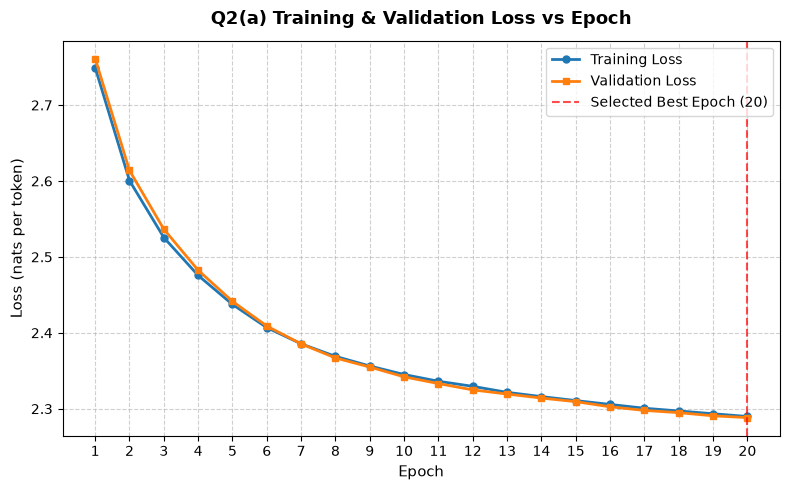

Selected Best Epoch:  Epoch 20
Best Validation Loss: 2.2883 nats per token
Final Test Loss:      2.3216 nats per token


In [13]:
epochs = range(1, 21)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, "o-", color="#1f77b4", label="Training Loss", linewidth=2, markersize=5)
plt.plot(epochs, val_losses, "s-", color="#ff7f0e", label="Validation Loss", linewidth=2, markersize=5)
plt.axvline(best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Selected Best Epoch ({best_epoch})")

plt.title("Q2(a) Training & Validation Loss vs Epoch", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Loss (nats per token)", fontsize=11)
plt.xticks(epochs)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()

# Restoring Best Checkpoint before Test Evaluation
embedding.load_state_dict(best_weights["embedding"])
network.load_state_dict(best_weights["network"])

# Evaluating on Test Set
test_loss = evaluate_q2(test_loader_q2)

# Final Results
print("=" * 60)
print(f"Selected Best Epoch:  Epoch {best_epoch}")
print(f"Best Validation Loss: {best_val_loss:.4f} nats per token")
print(f"Final Test Loss:      {test_loss:.4f} nats per token")
print("=" * 60)


##### Part (b): Generate names
Use the selected model to print one greedy name and five sampled names at each temperature: 0.5, 1, and 2. Start every name from the three start tokens. Greedy generation picks the largest logit; sampling uses:

```python
probabilities = torch.softmax(logits / temperature, dim=-1)
next_id = torch.multinomial(probabilities, num_samples=1)
```

After each choice, append the character and slide the context. Stop at the end token or after 20 letters. Mark empty outputs and those that hit the length limit. Reset seed 43 before each temperature’s group of five names. Repeated names are fine.

In [15]:
# Inverse vocabulary mapping
itos = {i: ch for ch, i in stoi.items()}

def generate_name(temperature=None, max_len=20):
    """
    Generates a single name.
    temperature=None -> Greedy decoding
    temperature=float -> Sampling with temperature
    """
    embedding.eval()
    network.eval()
    
    context = [stoi["-"]] * 3
    chars = []
    hit_limit = False
    
    with torch.no_grad():
        for _ in range(max_len):
            context_tensor = torch.tensor([context], dtype=torch.long, device=device)
            logits = network(embedding(context_tensor).reshape(-1, 6))
            
            if temperature is None:
                # Greedy: pick largest logit
                next_id = logits.argmax(dim=-1).item()
            else:
                # Sampling with temperature
                probabilities = torch.softmax(logits / temperature, dim=-1)
                next_id = torch.multinomial(probabilities, num_samples=1).item()
                
            if next_id == stoi["-"]:
                break
                
            chars.append(itos[next_id])
            context = context[1:] + [next_id]
        else:
            hit_limit = True
            
    name = "".join(chars)
    
    # Marking empty outputs and those that hit the 20-letter limit
    flags = []
    if len(name) == 0:
        flags.append("EMPTY")
    if hit_limit:
        flags.append("HIT LENGTH LIMIT (20 letters)")
        
    tag = f"  <-- {', '.join(flags)}" if flags else ""
    return name, tag

In [16]:
# Running generation for temperatures 0.5, 1.0, and 2.0
temperatures = [0.5, 1.0, 2.0]

for temp in temperatures:
    print(f"\n{'='*25} Temperature: {temp} {'='*25}")
    
    # One greedy name
    greedy_name, tag = generate_name(temperature=None)
    print(f"Greedy Name:      '{greedy_name}'{tag}")
    
    # Reset seed 43 before each temperature's group of five names
    set_seed(43)
    
    # Five sampled names
    print("5 Sampled Names:")
    for i in range(1, 6):
        sampled_name, tag = generate_name(temperature=temp)
        print(f"  {i}. '{sampled_name}'{tag}")



========================= Temperature: 0.5 =========================
Greedy Name:      'sara'
5 Sampled Names:
  1. 'ran'
  2. 'ran'
  3. 'bach'
  4. 'sanra'
  5. 'paj'

========================= Temperature: 1.0 =========================
Greedy Name:      'sara'
5 Sampled Names:
  1. 'rer'
  2. 'rainbach'
  3. 'suprame'
  4. 'julinkibaninditah'
  5. 'kosh'

========================= Temperature: 2.0 =========================
Greedy Name:      'sara'
5 Sampled Names:
  1. 'ref'
  2. 'roinbachcvmprach'
  3. 'julitkobaiinumtah'
  4. 'vosh'
  5. 'paf'


##### Part (c): Explain
In three or four sentences, explain why greedy generation repeats the same name from the same start, and describe how temperature affected your samples. All samples should come from the same trained model.

Greedy generation deterministically selects the character with the maximum logit ($\text{argmax}_k z_k$) at every step, so starting from the identical initial context ('---') guarantees an invariant, repeatable trajectory ('sara') with zero stochasticity. At $T = 0.5$, dividing logits by a value less than one sharpens the softmax distribution and concentrates probability mass onto the most frequent transitions, yielding conservative names and noticeable repetition (e.g., 'ran' sampled twice). At $T = 1.0$, the model samples directly from its learned distribution, generating diverse and phonotactically plausible names such as 'rainbach' and 'suprame'. Finally, at $T = 2.0$, the softmax distribution flattens toward uniform entropy, giving low-probability characters a substantial chance of selection and leading to long, chaotic, and atypical letter combinations (such as 'roinbachcvmprach').

#### Q3. What does the causal mask do?
This question uses three made-up token vectors and fixed weights. There is no dataset to split and no model to train.

```python
E = torch.tensor([[1.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 1.0]])
W_q = torch.eye(2)
W_k = torch.eye(2)
W_v = torch.eye(2)
W_o = torch.eye(2)
```

In [17]:
E = torch.tensor([[1.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 1.0]])
W_q = torch.eye(2)
W_k = torch.eye(2)
W_v = torch.eye(2)
W_o = torch.eye(2)

#### Part (a): Calculate attention
Write a function that returns the attention matrix and updated token vectors, once with a causal mask and once without it. The code below uses Python’s matrix-multiplication operator:

```python
Q = E @ W_q
K = E @ W_k
V = E @ W_v
scores = (Q @ K.transpose(-2, -1)) / (2 ** 0.5)

# For the causal run, mask future scores here, before softmax.
A = torch.softmax(scores, dim=-1)
updated = E + (A @ V) @ W_o
```

For query row i, set scores in columns j greater than i to negative infinity in the causal run. Keep the diagonal. Softmax runs across each row, over source tokens. Both returned arrays have three rows; A has three columns and updated has two.

Print A and updated for both runs. Check that each attention row sums to 1 and that masked future weights are zero.

##### Part (b) Show the Mask
Plot the two 3-by-3 attention matrices side by side, with the same colour scale from 0 to 1. Label rows as query positions and columns as source positions, numbered 0, 1, and 2.

##### Part (c): Change a future token
Replace the last input vector and repeat both calculations:

```python
changed_E = E.clone()
changed_E[2] = torch.tensor([4.0, 4.0])
```

For each mask setting, report the largest absolute change in the first two updated rows. Then explain in three or four sentences why the causal version keeps those rows unchanged and how this prevents a next-token predictor from seeing future inputs. Tiny floating-point differences are acceptable.